# Balaagh AI — CAMeLBERT-DA Multi-Task Classification

**Samsung Innovation Campus — AI Course Capstone Project**

This notebook contains the **original CAMeLBERT-DA training pipeline** used for Balaagh AI.  
It follows the SIC Capstone Notebook Template structure while preserving the original training approach and hyperparameters.

## 1. Overview

This notebook trains and evaluates a dialectal Arabic transformer model for **Balaagh AI**, an AI-powered crisis report analysis and decision-support platform.

The notebook performs **multi-task text classification** on Arabic and Libyan-style crisis reports using the pretrained **CAMeLBERT-DA** model (`CAMeL-Lab/bert-base-arabic-camelbert-da`).

The model predicts two outputs from the same report:

- **Incident Type:** 6 classes.
- **Priority Level:** 4 classes.

**Task:** Multi-task text classification  
**Model:** CAMeLBERT-DA  
**Framework:** PyTorch + Hugging Face Transformers

In [1]:
# ============================================================
# 1. Environment setup
# ============================================================
!pip install -q transformers datasets scikit-learn seaborn matplotlib accelerate


In [2]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support, classification_report
from torch.utils.data import Dataset, DataLoader


from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
def compute_full_metrics(y_true, y_pred) -> dict:
    accuracy = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
    }


In [3]:
# ============================================================
# 2. Configuration
# ============================================================
class CFG:
    MODEL_NAME = "CAMeL-Lab/bert-base-arabic-camelbert-da"
    MAX_LEN = 128
    BATCH_SIZE = 16
    EPOCHS = 5
    LR = 3e-5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # File paths - edit if your files live elsewhere (e.g. Google Drive)
    TRAIN_PATH = "train.csv"
    VAL_PATH = "val.csv"
    TEST_PATH = "test.csv"

    # Candidate column names the loader will try, in order
    TEXT_COL_CANDIDATES = ["report", "post text", "text"]
    INCIDENT_COL_CANDIDATES = ["incident_type", "type", "post text.1"]
    PRIORITY_COL_CANDIDATES = ["priority", "priority level"]

    INCIDENT_CLASSES = [
        "Infrastructure/Utilities",
        "Road/Transportation",
        "Fire/Explosion",
        "People at Risk/Medical",
        "Flood/Severe Weather",
        "Other",
    ]
    PRIORITY_CLASSES = ["Critical", "High", "Medium", "Low"]

    OUTPUT_DIR = "multitask_camelbert_output"

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
print(f"Using device: {CFG.DEVICE}")


Using device: cuda


## 2. Dataset

The Balaagh dataset contains **1,180 Arabic crisis reports** and is already divided into:

- **Training set:** 826 reports (70%)
- **Validation set:** 118 reports (10%)
- **Test set:** 236 reports (20%)

The main fields used by this notebook are the Arabic report text, `incident_type`, and `priority`.  
The six incident classes are:

1. Fire/Explosion
2. Flood/Severe Weather
3. Infrastructure/Utilities
4. Road/Transportation
5. People at Risk/Medical
6. Other

The four priority classes are:

1. Critical
2. High
3. Medium
4. Low

The existing Train/Validation/Test split is loaded directly and is not re-created inside the notebook.

In [4]:
# ============================================================
# 3. Data loading & cleaning
# ============================================================

def pick_column(df: pd.DataFrame, candidates: list, required: bool = True) -> str:
    """Return the first matching column name from `candidates` present in df."""
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of the candidate columns {candidates} found. "
                        f"Available columns: {list(df.columns)}")
    return None


def clean_text(text: str) -> str:
    """Normalize whitespace / strip hidden formatting characters commonly
    found in scraped social-media text (RLM/LRM marks, non-breaking spaces,
    stray newlines/tabs, repeated spaces)."""
    if not isinstance(text, str):
        return ""
    text = text.replace("\u00a0", " ").replace("\u200f", "").replace("\u200e", "")
    text = text.replace("\u202b", "").replace("\u202c", "")
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r" +", " ", text).strip()
    return text


def standardize_priority(value: str) -> str:
    """CRUCIAL cleaning step: collapse noisy casing variants
    ('HIGH', 'High', 'high', 'LOW', 'low', 'CRITICAL', 'Critical',
     'MEDIUM', 'Medium', ...) into exactly the 4 canonical labels
    ['Critical', 'High', 'Medium', 'Low']."""
    if not isinstance(value, str):
        return None
    v = value.strip().lower()
    mapping = {
        "critical": "Critical",
        "high": "High",
        "medium": "Medium",
        "med": "Medium",
        "low": "Low",
    }
    return mapping.get(v, value.strip().capitalize())


def standardize_incident_type(value: str, allowed: list) -> str:
    """Best-effort normalization for incident_type strings: trims whitespace
    and fixes casing; falls back to 'Other' if the value is not in the
    allowed class list after normalization (logged, not silently dropped)."""
    if not isinstance(value, str):
        return "Other"
    v = value.strip()
    for cls in allowed:
        if v.lower() == cls.lower():
            return cls
    return v  # leave as-is; unseen categories are reported below


def load_and_clean_split(path: str, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    text_col = pick_column(df, CFG.TEXT_COL_CANDIDATES)
    incident_col = pick_column(df, CFG.INCIDENT_COL_CANDIDATES)
    priority_col = pick_column(df, CFG.PRIORITY_COL_CANDIDATES)

    df = df.rename(columns={
        text_col: "text",
        incident_col: "incident_type",
        priority_col: "priority",
    })[["text", "incident_type", "priority"]].copy()

    before = len(df)
    df["text"] = df["text"].apply(clean_text)
    df["priority"] = df["priority"].apply(standardize_priority)
    df["incident_type"] = df["incident_type"].apply(
        lambda v: standardize_incident_type(v, CFG.INCIDENT_CLASSES)
    )

    # Drop rows with empty text or missing labels after cleaning
    df = df[(df["text"].str.len() > 0)
            & df["incident_type"].notna()
            & df["priority"].notna()].reset_index(drop=True)

    dropped = before - len(df)
    print(f"[{split_name}] loaded {before} rows, kept {len(df)} "
          f"({dropped} dropped for empty text / missing labels)")

    unseen_incident = sorted(set(df["incident_type"]) - set(CFG.INCIDENT_CLASSES))
    unseen_priority = sorted(set(df["priority"]) - set(CFG.PRIORITY_CLASSES))
    if unseen_incident:
        print(f"  WARNING: unseen incident_type values in {split_name}: {unseen_incident}")
    if unseen_priority:
        print(f"  WARNING: unseen priority values in {split_name}: {unseen_priority}")

    return df


train_df = load_and_clean_split(CFG.TRAIN_PATH, "train")
val_df = load_and_clean_split(CFG.VAL_PATH, "val")
test_df = load_and_clean_split(CFG.TEST_PATH, "test")

print("\nPriority distribution (train, after cleaning):")
print(train_df["priority"].value_counts())
print("\nIncident type distribution (train, after cleaning):")
print(train_df["incident_type"].value_counts())


[train] loaded 826 rows, kept 826 (0 dropped for empty text / missing labels)
[val] loaded 118 rows, kept 118 (0 dropped for empty text / missing labels)
[test] loaded 236 rows, kept 236 (0 dropped for empty text / missing labels)

Priority distribution (train, after cleaning):
priority
High        276
Medium      237
Critical    162
Low         151
Name: count, dtype: int64

Incident type distribution (train, after cleaning):
incident_type
Infrastructure/Utilities    158
Road/Transportation         156
Fire/Explosion              152
People at Risk/Medical      148
Flood/Severe Weather        114
Other                        98
Name: count, dtype: int64


### Dataset Overview

The following preparation stage verifies the required columns, cleans the report text, removes unusable rows, and prepares fixed label mappings. Fixed mappings are used so that class indices remain identical across the training, validation, and test sets.

In [5]:
# ============================================================
# 4. Label encoding (fixed, explicit mappings — not fit from data,
#    so the class index space is guaranteed identical across
#    train/val/test/inference regardless of which labels appear
#    in a given split).
# ============================================================

incident_le = LabelEncoder()
incident_le.classes_ = np.array(CFG.INCIDENT_CLASSES)

priority_le = LabelEncoder()
priority_le.classes_ = np.array(CFG.PRIORITY_CLASSES)

INCIDENT2IDX = {c: i for i, c in enumerate(CFG.INCIDENT_CLASSES)}
IDX2INCIDENT = {i: c for c, i in INCIDENT2IDX.items()}
PRIORITY2IDX = {c: i for i, c in enumerate(CFG.PRIORITY_CLASSES)}
IDX2PRIORITY = {i: c for c, i in PRIORITY2IDX.items()}

def encode_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Any incident_type value not in the fixed class list is folded into "Other"
    df["incident_type"] = df["incident_type"].apply(
        lambda v: v if v in INCIDENT2IDX else "Other"
    )
    df["incident_label"] = df["incident_type"].map(INCIDENT2IDX)
    df["priority_label"] = df["priority"].map(PRIORITY2IDX)
    n_before = len(df)
    df = df.dropna(subset=["incident_label", "priority_label"]).reset_index(drop=True)
    if len(df) < n_before:
        print(f"Dropped {n_before - len(df)} rows with unmappable labels.")
    df["incident_label"] = df["incident_label"].astype(int)
    df["priority_label"] = df["priority_label"].astype(int)
    return df

train_df = encode_labels(train_df)
val_df = encode_labels(val_df)
test_df = encode_labels(test_df)

print(f"Final sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")


Final sizes -> train: 826, val: 118, test: 236


## 3. Data Preprocessing

The original training pipeline performs text preparation before tokenization and converts the target labels into fixed numerical IDs.

CAMeLBERT-DA uses its pretrained **BertTokenizer / WordPiece tokenizer**. Reports are tokenized with a maximum sequence length of **128 tokens**, with padding and truncation enabled.

The tokenized samples are then wrapped in PyTorch datasets and data loaders for training, validation, and testing.

In [6]:
# ============================================================
# 5. Tokenizer, PyTorch Dataset, DataLoaders
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(CFG.MODEL_NAME)


class CrisisReportDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = 128):
        self.texts = df["text"].tolist()
        self.incident_labels = df["incident_label"].tolist()
        self.priority_labels = df["priority_label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "incident_label": torch.tensor(self.incident_labels[idx], dtype=torch.long),
            "priority_label": torch.tensor(self.priority_labels[idx], dtype=torch.long),
        }


train_dataset = CrisisReportDataset(train_df, tokenizer, CFG.MAX_LEN)
val_dataset = CrisisReportDataset(val_df, tokenizer, CFG.MAX_LEN)
test_dataset = CrisisReportDataset(test_df, tokenizer, CFG.MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Batches -> train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/305k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Batches -> train: 52, val: 8, test: 15


## 4. Model / Method

The model uses the pretrained **CAMeLBERT-DA encoder**, which was selected because it is pretrained for Dialectal Arabic and is suitable for informal Arabic text.

A shared CAMeLBERT representation is passed to two parallel classification heads:

- `incident_head`: predicts 6 incident classes.
- `priority_head`: predicts 4 priority classes.

The model uses **full fine-tuning**, so the transformer encoder and both classification heads are updated during training.

In [7]:
# ============================================================
# 6. Multi-task model definition
# ============================================================

class MultiTaskCAMeLBERT(nn.Module):
    """Shared CAMeLBERT-DA encoder + two linear classification heads."""

    def __init__(self, model_name: str, n_incident_classes: int, n_priority_classes: int,
                 dropout: float = 0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.incident_head = nn.Linear(hidden_size, n_incident_classes)
        self.priority_head = nn.Linear(hidden_size, n_priority_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        # BERT-style pooler output (tanh-activated [CLS]) if available,
        # otherwise fall back to the raw [CLS] token from last_hidden_state.
        if getattr(outputs, "pooler_output", None) is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0, :]

        pooled = self.dropout(pooled)
        incident_logits = self.incident_head(pooled)
        priority_logits = self.priority_head(pooled)
        return incident_logits, priority_logits


model = MultiTaskCAMeLBERT(
    CFG.MODEL_NAME,
    n_incident_classes=len(CFG.INCIDENT_CLASSES),
    n_priority_classes=len(CFG.PRIORITY_CLASSES),
).to(CFG.DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Total parameters: {n_params:,}")


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  439MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-da
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Model loaded. Total parameters: 109,089,034


In [8]:
# ============================================================
# 7. Optimizer, scheduler, loss
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

priority_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(list(range(len(CFG.PRIORITY_CLASSES)))),
    y=train_df["priority_label"].values
)

priority_weights_tensor = torch.tensor(priority_class_weights, dtype=torch.float).to(CFG.DEVICE)

print("Priority Class Weights applied:")
for idx, w in enumerate(priority_class_weights):
    print(f"  -> {IDX2PRIORITY[idx]}: {w:.4f}")

incident_criterion = nn.CrossEntropyLoss()
priority_criterion = nn.CrossEntropyLoss(weight=priority_weights_tensor)

no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": CFG.WEIGHT_DECAY,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=CFG.LR)

total_steps = len(train_loader) * CFG.EPOCHS
warmup_steps = int(CFG.WARMUP_RATIO * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"\nTotal training steps: {total_steps} (warmup: {warmup_steps})")


Priority Class Weights applied:
  -> Critical: 1.2747
  -> High: 0.7482
  -> Medium: 0.8713
  -> Low: 1.3675

Total training steps: 260 (warmup: 26)


## 5. Training / Processing

The original model is trained for **5 epochs** using AdamW and a linear warmup scheduler.

Main settings:

- Batch size: 16
- Maximum sequence length: 128
- Learning rate: 3e-5
- Warmup ratio: 0.1
- Random seed: 42
- Incident loss: standard CrossEntropyLoss
- Priority loss: class-weighted CrossEntropyLoss
- Original multi-task objective: `incident_loss + priority_loss`

The validation set is used to monitor performance and select the best checkpoint. The held-out test set is reserved for final evaluation.

In [9]:
# ============================================================
# 8. Train / evaluate epoch helpers
# ============================================================

def run_epoch(model, loader, optimizer=None, scheduler=None, train: bool = True):
    model.train() if train else model.eval()

    total_loss, total_incident_loss, total_priority_loss = 0.0, 0.0, 0.0
    all_incident_preds, all_incident_true = [], []
    all_priority_preds, all_priority_true = [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            incident_labels = batch["incident_label"].to(CFG.DEVICE)
            priority_labels = batch["priority_label"].to(CFG.DEVICE)

            if train:
                optimizer.zero_grad()

            incident_logits, priority_logits = model(input_ids, attention_mask)

            loss_incident = incident_criterion(incident_logits, incident_labels)
            loss_priority = priority_criterion(priority_logits, priority_labels)
            loss = loss_incident + loss_priority

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            total_incident_loss += loss_incident.item()
            total_priority_loss += loss_priority.item()

            all_incident_preds.extend(incident_logits.argmax(dim=1).cpu().numpy())
            all_incident_true.extend(incident_labels.cpu().numpy())
            all_priority_preds.extend(priority_logits.argmax(dim=1).cpu().numpy())
            all_priority_true.extend(priority_labels.cpu().numpy())

    n = len(loader)
    summary = {
        "loss": total_loss / n,
        "incident_loss": total_incident_loss / n,
        "priority_loss": total_priority_loss / n,
    }
    raw = {
        "incident_true": all_incident_true, "incident_pred": all_incident_preds,
        "priority_true": all_priority_true, "priority_pred": all_priority_preds,
    }
    return summary, raw

In [11]:
# ============================================================
# 9. Training Loop
# 5 Epochs, Validation Tracking, and Best Checkpoint Saving
# ============================================================

metrics_rows = []
history = []

best_val_score = -1.0
best_model_path = os.path.join(CFG.OUTPUT_DIR, "best_model.pt")

pd.set_option("display.float_format", "{:.6f}".format)


# Define the two classification tasks and their corresponding keys
TASKS = [
    ("incident_type", "incident_true", "incident_pred", "incident_loss"),
    ("priority", "priority_true", "priority_pred", "priority_loss"),]


for epoch in range(1, CFG.EPOCHS + 1):

    # Run one complete training epoch
    train_summary, train_raw = run_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        train=True,)

    # Evaluate the model on the validation set
    val_summary, val_raw = run_epoch(
        model,
        val_loader,
        train=False,)

    epoch_rows = []

    # Calculate validation metrics for each classification task
    for task_name, true_key, pred_key, loss_key in TASKS:

        val_task_metrics = compute_full_metrics(
            val_raw[true_key],
            val_raw[pred_key], )

        row = {
            "Epoch": epoch,
            "Task": task_name,
            "Training Loss": round(train_summary[loss_key], 6),
            "Validation Loss": round(val_summary[loss_key], 6),
            "Macro F1": round(val_task_metrics["macro_f1"], 6),
            "Weighted F1": round(val_task_metrics["weighted_f1"], 6),
            "Macro Precision": round(val_task_metrics["macro_precision"], 6),
            "Macro Recall": round(val_task_metrics["macro_recall"], 6),
            "Accuracy": round(val_task_metrics["accuracy"], 6), }

        epoch_rows.append(row)
        metrics_rows.append(row)


    # Display validation results for the current epoch
    epoch_df = pd.DataFrame(epoch_rows)

    print(f"\n=== Epoch {epoch}/{CFG.EPOCHS} — Validation Metrics ===")
    display(epoch_df)


    # Calculate the average Macro F1 across both tasks
    incident_macro_f1 = next(
        row["Macro F1"]
        for row in epoch_rows
        if row["Task"] == "incident_type")

    priority_macro_f1 = next(
        row["Macro F1"]
        for row in epoch_rows
        if row["Task"] == "priority")

    val_score = (incident_macro_f1 + priority_macro_f1) / 2


    # Store loss history for later visualization and analysis
    history.append({
        "epoch": epoch,
        "train_loss": train_summary["loss"],
        "val_loss": val_summary["loss"],
        "train_incident_loss": train_summary["incident_loss"],
        "val_incident_loss": val_summary["incident_loss"],
        "train_priority_loss": train_summary["priority_loss"],
        "val_priority_loss": val_summary["priority_loss"],})


    # Save the checkpoint with the best validation Macro F1 score
    if val_score > best_val_score:

        best_val_score = val_score

        torch.save(
            model.state_dict(),
            best_model_path,)

        print(
            f"  -> New best model saved "
            f"(Average Macro F1: {best_val_score:.6f})")


# Convert the collected results into DataFrames
metrics_df = pd.DataFrame(metrics_rows)
history_df = pd.DataFrame(history)


# Display the complete training and validation metrics
print("\n=== Full Per-Epoch Metrics — All Tasks ===")
display(metrics_df)


=== Epoch 1/5 — Validation Metrics ===


,Epoch,Task,Training Loss,Validation Loss,Macro F1,Weighted F1,Macro Precision,Macro Recall,Accuracy
0,1,incident_type,1.065823,0.822889,0.743782,0.754900,0.835831,0.734933,0.762712
1,1,priority,1.197044,1.158975,0.407372,0.405682,0.406762,0.420119,0.406780


  -> New best model saved (Average Macro F1: 0.575577)

=== Epoch 2/5 — Validation Metrics ===


,Epoch,Task,Training Loss,Validation Loss,Macro F1,Weighted F1,Macro Precision,Macro Recall,Accuracy
0,2,incident_type,0.487537,0.600550,0.827224,0.832653,0.832222,0.829832,0.830508
1,2,priority,0.945975,1.026563,0.496086,0.484164,0.509797,0.504015,0.483051


  -> New best model saved (Average Macro F1: 0.661655)

=== Epoch 3/5 — Validation Metrics ===


...

,Epoch,Task,Training Loss,Validation Loss,Macro F1,Weighted F1,Macro Precision,Macro Recall,Accuracy
0,4,incident_type,0.193676,0.545810,0.865684,0.865890,0.879789,0.860496,0.864407
1,4,priority,0.561169,0.968877,0.605817,0.607344,0.622626,0.601275,0.610169


  -> New best model saved (Average Macro F1: 0.735750)

=== Epoch 5/5 — Validation Metrics ===


,Epoch,Task,Training Loss,Validation Loss,Macro F1,Weighted F1,Macro Precision,Macro Recall,Accuracy
0,5,incident_type,0.170296,0.544638,0.846335,0.848772,0.867811,0.838787,0.847458
1,5,priority,0.490017,0.957481,0.632270,0.633674,0.639880,0.629470,0.635593


  -> New best model saved (Average Macro F1: 0.739302)

=== Full Per-Epoch Metrics — All Tasks ===


,Epoch,Task,Training Loss,Validation Loss,Macro F1,Weighted F1,Macro Precision,Macro Recall,Accuracy
0,1,incident_type,1.065823,0.822889,0.743782,0.754900,0.835831,0.734933,0.762712
1,1,priority,1.197044,1.158975,0.407372,0.405682,0.406762,0.420119,0.406780
2,2,incident_type,0.487537,0.600550,0.827224,0.832653,0.832222,0.829832,0.830508
3,2,priority,0.945975,1.026563,0.496086,0.484164,0.509797,0.504015,0.483051
4,3,incident_type,0.267364,0.584494,0.815380,0.821017,0.852237,0.805662,0.822034
5,3,priority,0.733718,0.981450,0.564835,0.557259,0.574826,0.576048,0.567797
6,4,incident_type,0.193676,0.545810,0.865684,0.865890,0.879789,0.860496,0.864407
7,4,priority,0.561169,0.968877,0.605817,0.607344,0.622626,0.601275,0.610169
8,5,incident_type,0.170296,0.544638,0.846335,0.848772,0.867811,0.838787,0.847458
9,5,priority,0.490017,0.957481,0.632270,0.633674,0.639880,0.629470,0.635593


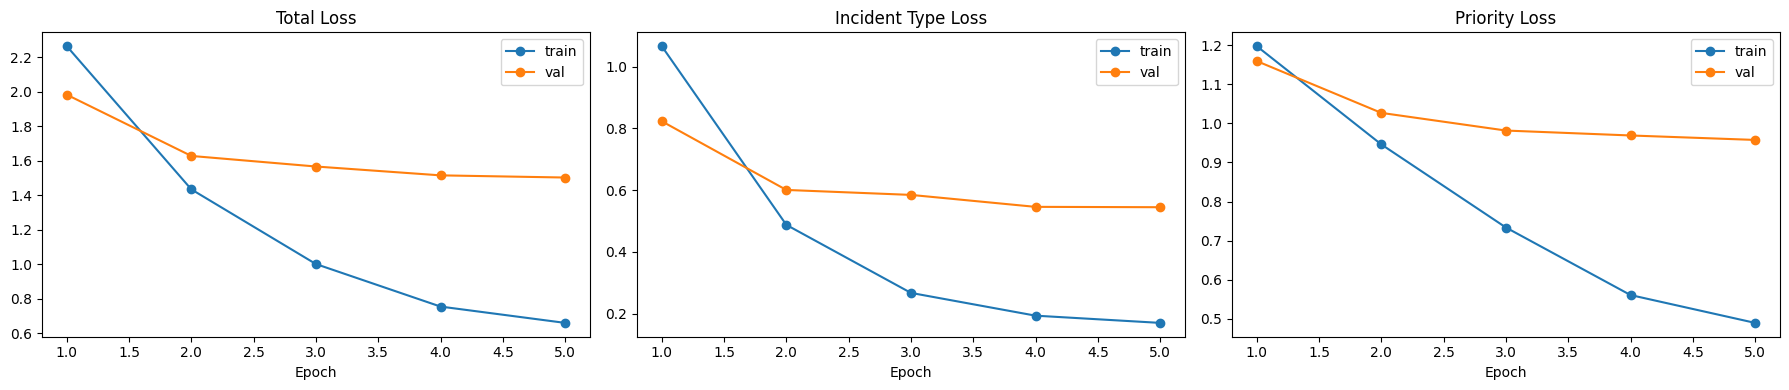

In [12]:
# ============================================================
# 10. Training curves
# ============================================================
# ============================================================
# 10. Training curves (Losses)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Total Loss
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# 2. Incident Loss
axes[1].plot(history_df["epoch"], history_df["train_incident_loss"], marker="o", label="train")
axes[1].plot(history_df["epoch"], history_df["val_incident_loss"], marker="o", label="val")
axes[1].set_title("Incident Type Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# 3. Priority Loss
axes[2].plot(history_df["epoch"], history_df["train_priority_loss"], marker="o", label="train")
axes[2].plot(history_df["epoch"], history_df["val_priority_loss"], marker="o", label="val")
axes[2].set_title("Priority Loss")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()


### Training / Processing Observations

Training and validation loss and Macro F1 are tracked across epochs. In the original experiment, the best checkpoint was selected from validation performance rather than simply using the final epoch. The training curves can be used to inspect convergence and possible overfitting.

## 6. Evaluation & Results

The best saved checkpoint is loaded before final evaluation.

The notebook evaluates both tasks using:

- Accuracy
- Precision
- Recall
- Macro F1-score
- Weighted F1-score
- Per-class classification reports
- Confusion matrices

The full held-out test set contains **236 reports**. A separate real-only locally sourced subset is also evaluated to examine performance on genuine Libyan-style reports.

In [13]:
# ============================================================
# 11. Load best checkpoint before final test evaluation
# ============================================================

model.load_state_dict(torch.load(best_model_path, map_location=CFG.DEVICE))
model.to(CFG.DEVICE)
model.eval()
print(f"Loaded best checkpoint from {best_model_path} (val avg macro-F1: {best_val_score:.4f})")


Loaded best checkpoint from multitask_camelbert_output/best_model.pt (val avg macro-F1: 0.7393)


In [14]:
# ============================================================
# 12. Final evaluation on test.csv
# ============================================================

def get_predictions(model, loader):
    all_incident_preds, all_incident_true = [], []
    all_priority_preds, all_priority_true = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            incident_labels = batch["incident_label"].to(CFG.DEVICE)
            priority_labels = batch["priority_label"].to(CFG.DEVICE)

            incident_logits, priority_logits = model(input_ids, attention_mask)

            all_incident_preds.extend(incident_logits.argmax(dim=1).cpu().numpy())
            all_incident_true.extend(incident_labels.cpu().numpy())
            all_priority_preds.extend(priority_logits.argmax(dim=1).cpu().numpy())
            all_priority_true.extend(priority_labels.cpu().numpy())
    return (np.array(all_incident_true), np.array(all_incident_preds),
            np.array(all_priority_true), np.array(all_priority_preds))


incident_true, incident_pred, priority_true, priority_pred = get_predictions(model, test_loader)

test_incident_acc = accuracy_score(incident_true, incident_pred)
test_incident_f1 = f1_score(incident_true, incident_pred, average="macro")
test_priority_acc = accuracy_score(priority_true, priority_pred)
test_priority_f1 = f1_score(priority_true, priority_pred, average="macro")

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Incident Type -> Accuracy: {test_incident_acc:.4f} | Macro F1: {test_incident_f1:.4f}")
print(f"Priority      -> Accuracy: {test_priority_acc:.4f} | Macro F1: {test_priority_f1:.4f}")

print("\n--- Classification Report: Incident Type ---")
print(classification_report(
    incident_true, incident_pred,
    target_names=CFG.INCIDENT_CLASSES, zero_division=0,
))

print("\n--- Classification Report: Priority ---")
print(classification_report(
    priority_true, priority_pred,
    target_names=CFG.PRIORITY_CLASSES, zero_division=0,
))


TEST SET RESULTS
Incident Type -> Accuracy: 0.8856 | Macro F1: 0.8832
Priority      -> Accuracy: 0.6144 | Macro F1: 0.6280

--- Classification Report: Incident Type ---
                          precision    recall  f1-score   support

Infrastructure/Utilities       0.86      0.84      0.85        45
     Road/Transportation       0.86      0.93      0.89        45
          Fire/Explosion       0.87      0.95      0.91        43
  People at Risk/Medical       1.00      0.86      0.92        42
    Flood/Severe Weather       0.85      0.88      0.87        33
                   Other       0.88      0.82      0.85        28

                accuracy                           0.89       236
               macro avg       0.89      0.88      0.88       236
            weighted avg       0.89      0.89      0.89       236


--- Classification Report: Priority ---
              precision    recall  f1-score   support

    Critical       0.77      0.77      0.77        43
        High      

In [15]:
# ============================================================
# Full Test Set Evaluation (236 Samples: Real + Generated)
# Per-Class Metrics and Urgent False-Negative Analysis
# ============================================================

# 1. Generate predictions for the complete test set
full_incident_true, full_incident_pred, full_priority_true, full_priority_pred = \
    get_predictions(model, test_loader)

print(f"Inference complete on ALL {len(test_df)} test reports (Full Dataset).\n")


# 2. Incident Type Classification Report
incident_report_dict = classification_report(
    full_incident_true,
    full_incident_pred,
    target_names=CFG.INCIDENT_CLASSES,
    output_dict=True,
    zero_division=0,
)

incident_report_df = pd.DataFrame(incident_report_dict).T

# Keep only the support value for the accuracy row
incident_report_df.loc[
    ["accuracy"], ["precision", "recall", "support"]
] = [np.nan, np.nan, len(full_incident_true)]

print(
    "=== 1. Incident Type Classification Report "
    "(Per-Class Metrics) — Full Test Set ==="
)

display(
    incident_report_df.style.format(
        "{:.4f}",
        na_rep="—"
    )
)


# 3. Priority Classification Report
# Critical and High are considered urgent priority levels
URGENT_CLASSES = {"High", "Critical"}

priority_report_dict = classification_report(
    full_priority_true,
    full_priority_pred,
    target_names=CFG.PRIORITY_CLASSES,
    output_dict=True,
    zero_division=0,
)

priority_report_df = pd.DataFrame(priority_report_dict).T

# Keep only the support value for the accuracy row
priority_report_df.loc[
    ["accuracy"], ["precision", "recall", "support"]
] = [np.nan, np.nan, len(full_priority_true)]


# Calculate the False Negative Rate (FNR) for each priority class
# FNR = 1 - Recall
fn_rate = pd.Series(
    index=priority_report_df.index,
    dtype=float
)

for cls in CFG.PRIORITY_CLASSES:
    fn_rate[cls] = 1.0 - priority_report_df.loc[cls, "recall"]

priority_report_df["false_negative_rate"] = fn_rate


# Highlight the False Negative Rate for urgent classes
def highlight_urgent_fn(row):
    if row.name in URGENT_CLASSES:
        return [
            "background-color: #FDECEC"
            if col == "false_negative_rate"
            else ""
            for col in row.index
        ]

    return ["" for _ in row.index]


styled_priority = (
    priority_report_df
    .style
    .format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:.0f}",
            "false_negative_rate": "{:.2%}",
        },
        na_rep="—",
    )
    .apply(highlight_urgent_fn, axis=1)
)


print(
    "\n=== 2. Priority Level Evaluation & "
    "Urgent False-Negative Analysis — Full Test Set ==="
)

display(styled_priority)


# 4. Binary Urgent vs. Non-Urgent Evaluation
# Urgent: Critical or High
# Non-Urgent: Medium or Low
urgent_idx = {
    PRIORITY2IDX[c]
    for c in URGENT_CLASSES
}


# Convert the four priority classes into binary urgent/non-urgent labels
true_urgent = np.array([
    1 if label in urgent_idx else 0
    for label in full_priority_true
])

pred_urgent = np.array([
    1 if label in urgent_idx else 0
    for label in full_priority_pred
])


# Calculate binary classification outcomes
true_positive = int(
    ((true_urgent == 1) & (pred_urgent == 1)).sum()
)

false_negative = int(
    ((true_urgent == 1) & (pred_urgent == 0)).sum()
)

false_positive = int(
    ((true_urgent == 0) & (pred_urgent == 1)).sum()
)

true_negative = int(
    ((true_urgent == 0) & (pred_urgent == 0)).sum()
)


# Calculate the False Negative Rate for urgent reports
total_urgent = true_positive + false_negative

urgent_fn_rate = (
    false_negative / total_urgent
    if total_urgent > 0
    else float("nan")
)


# Create a summary table for urgent-report detection
binary_summary = pd.DataFrame({
    "Metric": [
        "Truly urgent reports in full test set (High + Critical)",
        "Correctly flagged as urgent (True Positive)",
        "Missed — predicted Medium/Low when truly urgent (False Negative)",
        "False Negative Rate on urgent incidents",
        "Non-urgent reports incorrectly flagged as urgent (False Positive)",
    ],
    "Value": [
        total_urgent,
        true_positive,
        false_negative,
        f"{urgent_fn_rate:.2%}",
        false_positive,
    ],
})


print(
    "\n=== 3. Binary Urgent vs. Non-Urgent "
    "— False Negative Summary — Full Test Set ==="
)

display(binary_summary)

Inference complete on ALL 236 test reports (Full Dataset).

=== 1. Incident Type Classification Report (Per-Class Metrics) — Full Test Set ===


,precision,recall,f1-score,support
Infrastructure/Utilities,0.8636,0.8444,0.8539,45.0000
Road/Transportation,0.8571,0.9333,0.8936,45.0000
Fire/Explosion,0.8723,0.9535,0.9111,43.0000
People at Risk/Medical,1.0000,0.8571,0.9231,42.0000
Flood/Severe Weather,0.8529,0.8788,0.8657,33.0000
Other,0.8846,0.8214,0.8519,28.0000
accuracy,—,—,0.8856,236.0000
macro avg,0.8884,0.8814,0.8832,236.0000
weighted avg,0.8892,0.8856,0.8856,236.0000



=== 2. Priority Level Evaluation & Urgent False-Negative Analysis — Full Test Set ===


,precision,recall,f1-score,support,false_negative_rate
Critical,0.7674,0.7674,0.7674,43,23.26%
High,0.6118,0.6341,0.6228,82,36.59%
Medium,0.5070,0.5217,0.5143,69,47.83%
Low,0.6486,0.5714,0.6076,42,42.86%
accuracy,—,—,0.6144,236,—
macro avg,0.6337,0.6237,0.6280,236,—
weighted avg,0.6161,0.6144,0.6147,236,—



=== 3. Binary Urgent vs. Non-Urgent — False Negative Summary — Full Test Set ===


,Metric,Value
0,Truly urgent reports in full test set (High + ...,125
1,Correctly flagged as urgent (True Positive),100
2,Missed — predicted Medium/Low when truly urgen...,25
3,False Negative Rate on urgent incidents,20.00%
4,Non-urgent reports incorrectly flagged as urge...,28


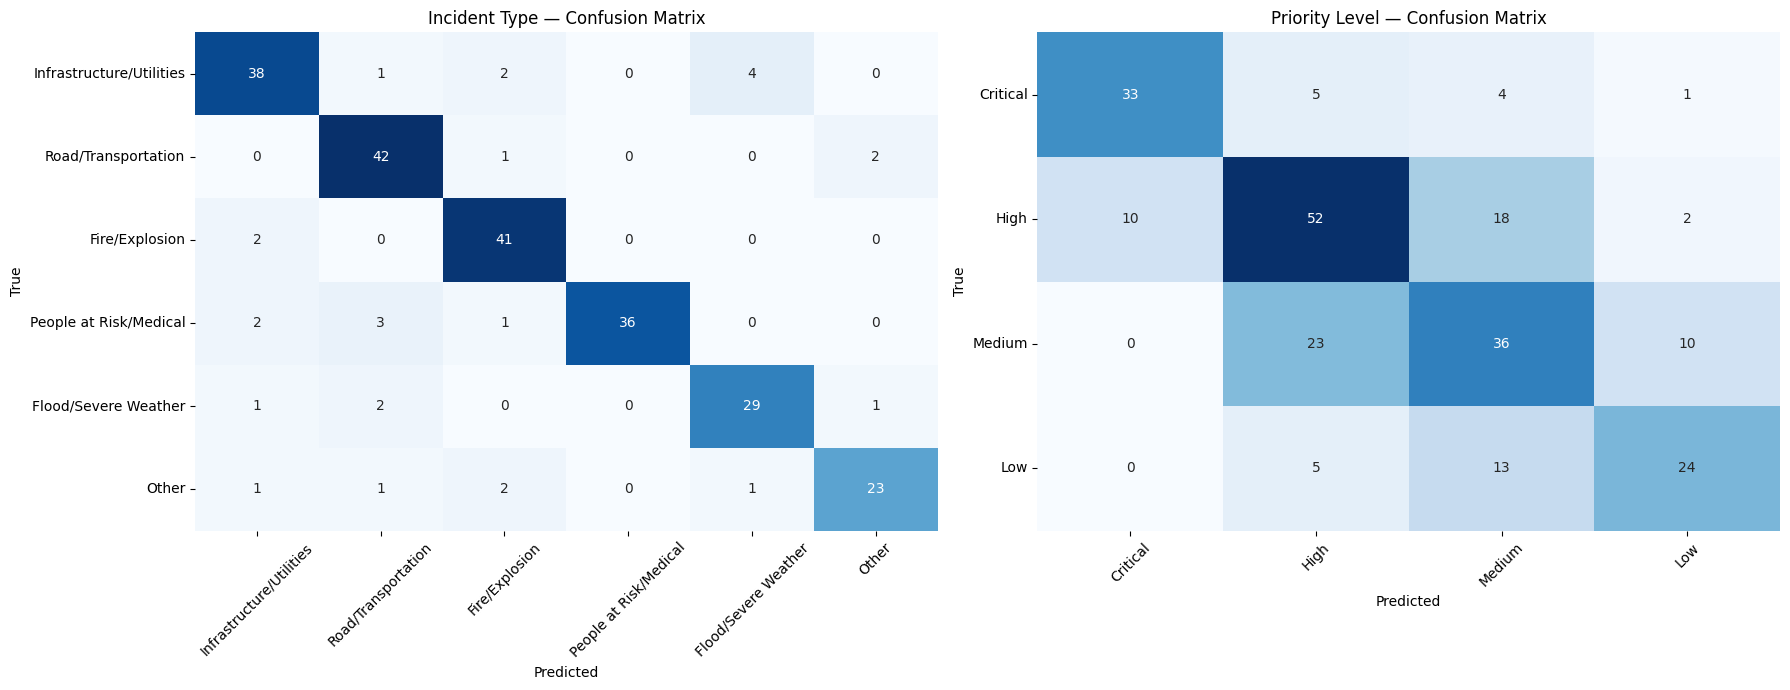

In [16]:
# ============================================================
# 13. Confusion matrices
# ============================================================

def plot_confusion_matrix(y_true, y_pred, class_names, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_confusion_matrix(incident_true, incident_pred, CFG.INCIDENT_CLASSES,
                       "Incident Type — Confusion Matrix", axes[0])
plot_confusion_matrix(priority_true, priority_pred, CFG.PRIORITY_CLASSES,
                       "Priority Level — Confusion Matrix", axes[1])
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "confusion_matrices.png"), dpi=150)
plt.show()


### Result Interpretation

In the original CAMeLBERT-DA experiment, **incident-type classification performed substantially better than priority classification**.

The priority task is more difficult because severity levels can overlap semantically, particularly between adjacent levels such as High and Medium. For this reason, the notebook also examines urgent-report false negatives rather than relying only on overall accuracy.

## 7. Error Analysis

Because Balaagh AI is a decision-support prototype for crisis reports, false negatives for urgent incidents are especially important.

The evaluation code analyzes:

- Per-class Precision, Recall, and F1.
- False-negative rates for priority classes.
- A binary **Urgent vs. Non-Urgent** view, where Critical and High are treated as urgent.
- Performance on the locally sourced real-only test subset.

These checks help identify where priority prediction requires further improvement while keeping human review in control.

## 8. Sample Predictions / Outputs

The following inference helper can be used to test the trained model on new Arabic or Libyan-dialect crisis reports. It returns the predicted incident type and priority level together with confidence scores.

In [17]:
# ============================================================
# 14. Inference helper: predict_report(text)
# ============================================================

def predict_report(text: str, model=model, tokenizer=tokenizer,
                    max_len: int = CFG.MAX_LEN, device=CFG.DEVICE) -> dict:
    """Predict incident_type and priority for a single raw Libyan-Arabic
    crisis report string. Returns a dict with readable string labels and
    the model's confidence for each prediction."""
    model.eval()
    cleaned = clean_text(text)

    encoding = tokenizer(
        cleaned,
        truncation=True,
        max_length=max_len,
        padding="max_length",
        return_tensors="pt",
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        incident_logits, priority_logits = model(input_ids, attention_mask)
        incident_probs = torch.softmax(incident_logits, dim=1).cpu().numpy()[0]
        priority_probs = torch.softmax(priority_logits, dim=1).cpu().numpy()[0]

    incident_idx = int(incident_probs.argmax())
    priority_idx = int(priority_probs.argmax())

    return {
        "text": text,
        "incident_type": IDX2INCIDENT[incident_idx],
        "incident_confidence": float(incident_probs[incident_idx]),
        "priority": IDX2PRIORITY[priority_idx],
        "priority_confidence": float(priority_probs[priority_idx]),
    }


# --- Example usage ---
# --- Example usage ---
examples = [
    "اندلاع حريق كبير في مستودع وقود بمنطقة السدرة مع انتشار سريع للنيران",
    "سيارة خشت في عمود إنارة في طريق الشط في طرابلس وفيه زوز مصابين",
    "انقطاع الكهرباء من ساعتين في المنطقة ومفيش رد من الشركة",
    "طنجرة ضغط انفجرت في المطبخ والدخان عبي الحوش وفي نساوين انحرقوا",

]

for ex in examples:
    result = predict_report(ex)
    print(f"Text: {result['text']}")
    print(f"  -> Incident Type: {result['incident_type']} "
          f"(confidence: {result['incident_confidence']:.2%})")
    print(f"  -> Priority      : {result['priority']} "
          f"(confidence: {result['priority_confidence']:.2%})\n")


Text: اندلاع حريق كبير في مستودع وقود بمنطقة السدرة مع انتشار سريع للنيران
  -> Incident Type: Fire/Explosion (confidence: 97.94%)
  -> Priority      : High (confidence: 41.52%)

Text: سيارة خشت في عمود إنارة في طريق الشط في طرابلس وفيه زوز مصابين
  -> Incident Type: Road/Transportation (confidence: 91.74%)
  -> Priority      : High (confidence: 59.51%)

Text: انقطاع الكهرباء من ساعتين في المنطقة ومفيش رد من الشركة
  -> Incident Type: Infrastructure/Utilities (confidence: 95.69%)
  -> Priority      : Medium (confidence: 56.61%)

Text: طنجرة ضغط انفجرت في المطبخ والدخان عبي الحوش وفي نساوين انحرقوا
  -> Incident Type: Fire/Explosion (confidence: 40.90%)
  -> Priority      : High (confidence: 47.10%)



## 9. Conclusion

This notebook implements the original Balaagh AI **CAMeLBERT-DA multi-task classification model** for incident-type and priority prediction.

The pipeline covers dataset loading, preprocessing, tokenization, model definition, full fine-tuning, validation-based checkpoint selection, final test evaluation, locally sourced evaluation, confusion matrices, false-negative analysis, and sample inference.

The original results show strong incident classification performance, while **priority classification remains the main area for improvement**. Future experiments can therefore focus on improved priority labels, task weighting, loss design, and additional high-quality training data without changing the held-out test set.

### Model Saving

The original notebook saves the best model checkpoint and label mappings so that the trained model can later be reloaded for inference or integrated into the Balaagh AI web platform.

In [18]:
# ============================================================
# 15. Persist label mappings alongside the checkpoint
# ============================================================

label_maps = {
    "incident_classes": CFG.INCIDENT_CLASSES,
    "priority_classes": CFG.PRIORITY_CLASSES,
    "model_name": CFG.MODEL_NAME,
    "max_len": CFG.MAX_LEN,
}
with open(os.path.join(CFG.OUTPUT_DIR, "label_maps.json"), "w", encoding="utf-8") as f:
    json.dump(label_maps, f, ensure_ascii=False, indent=2)

print(f"Saved best_model.pt, label_maps.json, training_curves.png, "
      f"confusion_matrices.png to ./{CFG.OUTPUT_DIR}/")


Saved best_model.pt, label_maps.json, training_curves.png, confusion_matrices.png to ./multitask_camelbert_output/
